In [1]:
# NBVAL_IGNORE_OUTPUT
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML

from pyramids.dataset import Dataset, DatasetCollection, GeoReference

%matplotlib inline
# Render at a modest dpi: to_jshtml embeds a PNG per frame, so a lower dpi keeps the
# inline animations compact.
plt.rcParams["figure.dpi"] = 80

# RGB true-colour animation with `DatasetCollection`

`DatasetCollection.plot` animates a temporal stack of co-registered rasters. By default it animates a **single
band** as a colormapped field. Passing `rgb_options` instead composites the requested bands of **every timestep**
into a true-colour frame, producing an RGB (or RGBA) time-lapse with one frame per timestep.

This is the feature added for issue #538 and it needs **cleopatra >= 0.20.0**.

## Build a multi-band time series

The bundled `rhine` example is single-band, so we synthesise a small 3-band (R, G, B) time series: five timesteps
of an `8`-bit image with a bright square that moves across the frame, written to a temporary folder.

In [2]:
rng = np.random.default_rng(0)
folder = tempfile.mkdtemp(prefix="rgb_cube_")
n_times, size = 5, 48

for t in range(n_times):
    # Low-level RGB noise plus a moving bright block so the animation is visible.
    arr = (rng.random((3, size, size)) * 60).astype("float32")
    r0 = 4 + t * 8
    arr[:, r0 : r0 + 8, r0 : r0 + 8] = 230.0
    Dataset.from_array(
        arr=arr, geo_ref=GeoReference(geo=(0, 1, 0, size, 0, -1), epsg=4326)
    ).to_file(os.path.join(folder, f"frame_{t:02d}.tif"))

sorted(os.listdir(folder))

['frame_00.tif',
 'frame_01.tif',
 'frame_02.tif',
 'frame_03.tif',
 'frame_04.tif']

Read the tiles back as a `DatasetCollection` — a time-stack of co-registered rasters.

In [3]:
cube = DatasetCollection.from_files(
    [os.path.join(folder, f) for f in sorted(os.listdir(folder))]
)
print("timesteps:", cube.time_length, "| bands per dataset:", cube.base.band_count)

timesteps: 5 | bands per dataset: 3


## Single-band animation (the default)

Without `rgb_options`, `plot` animates one band as a colormapped field — `glyph.arr` keeps the
`(time, rows, cols)` shape and the figure carries a colorbar.

arr shape: (5, 48, 48) | has colorbar: True


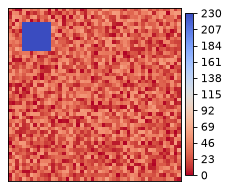

In [4]:
# NBVAL_IGNORE_OUTPUT
single = cube.plot(band=0, figsize=(3, 3))
print("arr shape:", single.arr.shape, "| has colorbar:", single.cbar is not None)

In [5]:
# NBVAL_IGNORE_OUTPUT
HTML(single.anim.to_jshtml())

## RGB true-colour animation

Pass `rgb_options={"rgb": [r, g, b], ...}` to composite a true-colour frame per timestep. The result's `arr` is
the `(time, rows, cols, 3)` display-ready stack, and `cbar` is `None` (true colour carries no colorbar). The
`percentile` stretch enhances contrast — every one of the five frames is preserved.

arr shape: (5, 48, 48, 3) | has colorbar: False


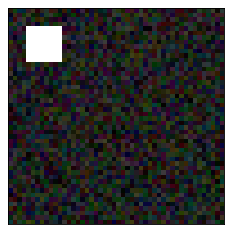

In [6]:
# NBVAL_IGNORE_OUTPUT
rgb = cube.plot(rgb_options={"rgb": [0, 1, 2], "percentile": 2}, figsize=(3, 3))
print("arr shape:", rgb.arr.shape, "| has colorbar:", rgb.cbar is not None)

In [7]:
# NBVAL_IGNORE_OUTPUT
HTML(rgb.anim.to_jshtml())

### Normalisation options

`rgb_options` groups the stretch controls that cleopatra's `prepare_array` understands:

- `percentile` — contrast stretch by clipping to the given percentile (takes precedence).
- `surface_reflectance` — divide by a fixed scale (e.g. `10000` for Sentinel-2, `255` for 8-bit imagery).
- `cutoff` — per-band clip values.

Use a four-index `rgb` (`[r, g, b, a]`) for an RGBA time-lapse — `arr` then ends in a `4` channel axis.

surface-reflectance stretch -> arr shape: (5, 48, 48, 3)
values normalised into [0, 1]: True


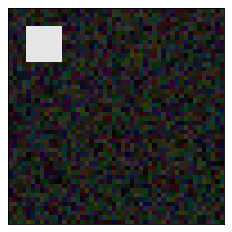

In [8]:
# NBVAL_IGNORE_OUTPUT
sr = cube.plot(
    rgb_options={"rgb": [0, 1, 2], "surface_reflectance": 255}, figsize=(3, 3)
)
print("surface-reflectance stretch -> arr shape:", sr.arr.shape)
print("values normalised into [0, 1]:", bool(sr.arr.min() >= 0 and sr.arr.max() <= 1))

## Validation and guards

The RGB path validates its inputs up front, so a malformed request fails with a clear message instead of silently
dropping frames (the #538 bug) or surfacing a cryptic cleopatra error:

- the `rgb` list must hold exactly 3 (RGB) or 4 (RGBA) indices,
- every index must be non-negative,
- the datasets must carry at least `max(rgb) + 1` bands,
- `exclude_value` is ignored for true-colour frames (passing it warns).

Seeing these errors in action is covered by the test suite, not this tutorial.